# Дискретно-событийная модель SIR: вакцинация

В момент $t_v$ часть здоровых людей мгновенно прививается и переходит
в группу $R$. Найдём, какая доля привитых нужна, чтобы эпидемия
не развилась. По теории для этого достаточно доли $1 - 1/R_0$,
что при $R_0 = 2$ составляет 50 %.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRDES) || include(srcdir("sir_model.jl"))
using .SIRDES
using Random, Plots, DataFrames, CSV, Statistics

script_name = "sir_des_vaccination"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab08/project/data"

## Набор параметров

Доля привитых меняется от 0 до 0.8, вакцинация проводится в момент 5,
и для каждой доли выполняется три прогона с разными зёрнами.

In [2]:
vac_dict = Dict(
    :fraction => collect(0.0:0.1:0.8),
    :t_vac => 5.0,
    :seed => [1, 2, 3],
    :tmax => 50.0,
)
vac_list = dict_list(vac_dict)
length(vac_list)

u0 = [990, 10, 0]
p = [0.05, 10.0, 0.25]

3-element Vector{Float64}:
  0.05
 10.0
  0.25

## Функция одного эксперимента

Функция возвращает число привитых, общее число заражений за всё время
и пик числа больных.

In [3]:
function run_vac(q)
    Random.seed!(q[:seed])
    m = MakeXModel(u0, p)
    activate_x(m; vaccination_time = q[:t_vac], fraction = q[:fraction])
    run_x(m, q[:tmax])
    df = out_x(m)
    return (
        fraction = q[:fraction],
        seed = q[:seed],
        vaccinated = m.vaccinated,
        infections = m.infections,
        peak_I = maximum(df.I),
    )
end

run_vac (generic function with 1 method)

## Запуск экспериментов

In [4]:
df_vac_all = DataFrame([run_vac(q) for q in vac_list])
df_vac = combine(
    groupby(df_vac_all, :fraction),
    :vaccinated => mean => :vaccinated,
    :infections => mean => :infections,
    :peak_I => mean => :peak_I,
)
sort!(df_vac, :fraction)
CSV.write(datadir("sir_des_vaccination.csv"), df_vac)
println(df_vac)

9×4 DataFrame
 Row │ fraction  vaccinated  infections  peak_I   
     │ Float64   Float64     Float64     Float64  
─────┼────────────────────────────────────────────
   1 │      0.0      0.0       771.667   174.333
   2 │      0.1     94.3333    632.667   111.0
   3 │      0.2    188.667     523.667    93.3333
   4 │      0.3    282.667     363.667    68.3333
   5 │      0.4    377.0       249.667    53.3333
   6 │      0.5    471.333     161.0      42.3333
   7 │      0.6    565.667     102.333    40.3333
   8 │      0.7    660.0        84.6667   37.6667
   9 │      0.8    754.0        69.0      37.6667


## Примеры динамики

Для наглядности построим число больных при трёх долях привитых.

In [5]:
curves = []
for f in [0.0, 0.3, 0.6]
    Random.seed!(1)
    m = MakeXModel(u0, p)
    activate_x(m; vaccination_time = 5.0, fraction = f)
    run_x(m, 50.0)
    push!(curves, (f, out_x(m)))
end

## Графики

Слева среднее число заражений в зависимости от доли привитых,
справа число больных для трёх долей.

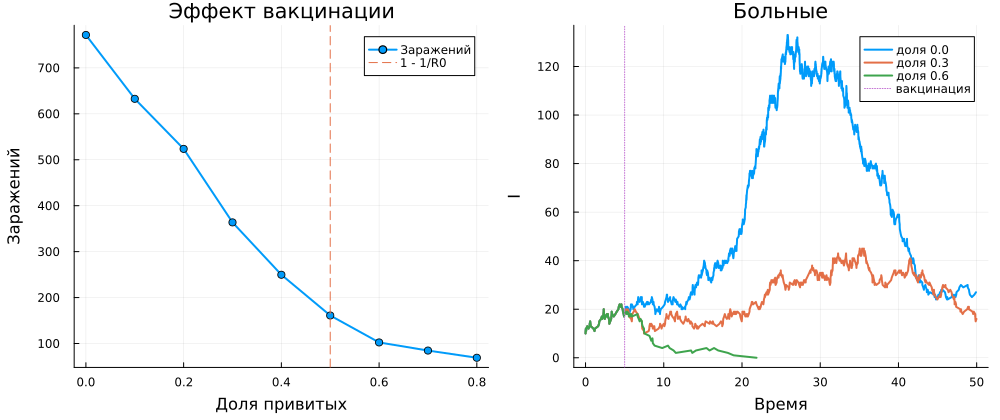

In [6]:
p1 = plot(df_vac.fraction, df_vac.infections, marker = :circle, linewidth = 2, label = "Заражений", xlabel = "Доля привитых", ylabel = "Заражений", title = "Эффект вакцинации")
vline!(p1, [0.5], linestyle = :dash, label = "1 - 1/R0")
p2 = plot(xlabel = "Время", ylabel = "I", title = "Больные")
for (f, d) in curves
    plot!(p2, d.t, d.I, linewidth = 2, label = "доля $f")
end
vline!(p2, [5.0], linestyle = :dot, label = "вакцинация")
plt_vac = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
savefig(plt_vac, plotsdir("sir_des_vaccination.png"))
plt_vac